# Invariant QPINN on a neutral-atom device (QoolQit)

- **Quantum model.**
  - Step 1 encodes $x$ and $t$ as Pauli-$Z$ rotations.
  - Step 2 is a trainable pulse with **4 parameters**.
- **Hard constraint.** $u_\theta(x,t)=u_0(x)+(1-\cos t)\,f(x,t)$, so the initial condition holds for every $\theta$.
- **Invariant QPINN.** $f(x,t)=\tfrac12\big[f_\theta(x,t)+f_\theta(-x,-t)\big]$: run the circuit at $(x,t)$ and at $(-x,-t)$, then average. This is group averaging over the sign flip (arXiv:2610.01874).
- **Plain QPINN.** $f=f_\theta$, with everything else the same.
- **PDE.** $u_t+u_x=-A\sin(x+t)$ with $u(x,0)=A\cos x$. The exact solution $u^\ast=A\cos x\cos t$ is even.
- **Training.**
  - Derivatives: two-term parameter-shift rule.
  - Optimizer: Levenberg–Marquardt via `scipy.optimize.least_squares(method="lm")`.
  - Runs: 3 seeds per model.
- **Backend.** `BACKEND = "qoolqit"` uses the QoolQit emulator; `"numpy"` uses an exact 4×4 simulation of the same Hamiltonian.

## 1. Quantum model

**Hamiltonian.** Two atoms at distance $r=1$, so $J=1$. There is one global laser and one detuning map (DMM) acting on atom 0 only:

$$H(\tau)=\frac{\Omega(\tau)}{2}(X_0+X_1)-\delta(\tau)\,(n_0+n_1)-\Delta(\tau)\,n_0+J\,n_0n_1,\qquad \Delta(\tau)\le 0 .$$

**Windows.**

- **Phase window $Z(a_0,a_1)$:** $\Omega=0$, with $\delta T=a_1$ and $(\delta+\Delta)T=a_0\pmod{2\pi}$. Then
  $$Z(a_0,a_1)\cong R_Z(a_0)\otimes R_Z(a_1)\cdot(\text{fixed }ZZ\text{ phase}).$$
- **Mixing window $M$:** $\Omega_MT_M=\pi/2$, with $\delta=\Delta=0$. It is fixed.
- **Preparation $P$:** a fixed window calibrated so that all four populations of $P|00\rangle$ are $1/4$. Without it, the $Z$ encoding acting on $|00\rangle$ would have no effect.

**Schedule** (total 2.6 µs):

| window | $P$ | $E$ | $M$ | $Z_1$ | $M$ | $Z_2$ | $M$ |
|---|---|---|---|---|---|---|---|
| duration (µs) | 0.5 | 0.5 | 0.4 | 0.2 | 0.4 | 0.2 | 0.4 |
| content | fixed | $Z(x,t)$ | fixed | $Z(\theta_0,\theta_1)$ | fixed | $Z(\theta_2,\theta_3)$ | fixed |

**Circuit output.**

$$f_\theta(x,t)=\langle00|\,U_\theta^\dagger Z_0U_\theta\,|00\rangle,\qquad U_\theta=M\,Z(\theta_2,\theta_3)\,M\,Z(\theta_0,\theta_1)\,M\;Z(x,t)\;P,$$

so

$$f_\theta(x,t)=\sum_{\omega_x,\omega_t\in\{-1,0,1\}}c_\omega(\theta)\,e^{\,i(\omega_xx+\omega_tt)} .$$

## 2. QPINN ansatz

**Hard constraint.**

$$u_\theta(x,t)=u_0(x)+m(t)\,f(x,t),\qquad m(t)=1-\cos t .$$

- Since $m(0)=0$, $u_\theta(x,0)=u_0(x)$ for every $\theta$, so the loss contains only the PDE residual.
- $m$ is even in $t$, so it does not break the symmetry below.
- Periodicity in $x$ is automatic.

**Plain QPINN:** $f=f_\theta$.

**Invariant QPINN:**

$$f(x,t)=\tfrac12\big[f_\theta(x,t)+f_\theta(-x,-t)\big]=\sum_\omega\mathrm{Re}\,c_\omega(\theta)\,\cos(\omega_xx+\omega_tt),$$

which is invariant under $(x,t)\to(-x,-t)$.

**Why the invariant model should do better.** The exact solution corresponds to $f^\ast=-A\cos x$.

- The invariant model contains only cosine terms. It has to match 4 cosine coefficients with 4 parameters.
- The plain model must also make its 4 sine coefficients vanish, which is 8 conditions for 4 parameters.

## 3. PDE and loss

$$u_t+u_x=-A\sin(x+t),\qquad x\in[-\pi,\pi)\ \text{(periodic)},\quad t\in[0,1],\qquad u(x,0)=A\cos x,\qquad A=0.5,$$

$$u^\ast(x,t)=A\cos x\cos t .$$

**Residual.** With the hard constraint,

$$r=\partial_tu_\theta+\partial_xu_\theta-s=\sin t\,f+(1-\cos t)\,(f_t+f_x)+u_0'(x)-s(x,t).$$

**Collocation points.** $x\in\{-\pi,-\tfrac\pi2,0,\tfrac\pi2\}$ and $t\in\{0.25,0.5,0.75,1\}$, i.e. 16 points.

**Loss.**

$$\mathcal L=\frac1{|\mathcal C|}\sum_{\mathcal C}r^2=\|R\|^2 .$$

## 4. Derivatives

Both models are degree-1 trigonometric polynomials in $x$, in $t$ and in each $\theta_k$, all with gap 1. So, with $s=\pi/2$, the two-term rule is exact:

$$\partial_xf=\tfrac12\big[f(x+s,t)-f(x-s,t)\big],\qquad \partial_tf=\tfrac12\big[f(x,t+s)-f(x,t-s)\big],\qquad \partial_{\theta_k}f=\tfrac12\big[f(\theta+s\,e_k)-f(\theta-s\,e_k)\big].$$

**Cost of one Jacobian.**

- The $x$-shifts land on grid points, which are cached. That leaves 48 points, each needing $1+2\cdot4=9$ evaluations of $f$.
- Plain QPINN: 432 circuit runs.
- Invariant QPINN: 864 circuit runs, since each $f$ needs two circuits.

In [1]:
import json
import os
import time
from functools import reduce

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import least_squares
from qoolqit import Register, Drive, QuantumProgram, AnalogDeviceWithDMM, ConstantWaveform
from qoolqit.drive import DetuningMapModulator
from qoolqit.execution import LocalEmulator, EmulationConfig, Occupation

BACKEND = "qoolqit"                        # "qoolqit": QoolQit emulator   |   "numpy": exact 4x4 simulation, same Hamiltonian
RESULTS_DIR = "results_invariant_qpinn"
os.makedirs(RESULTS_DIR, exist_ok=True)

COORDS = [(0.0, 0.0), (1.0, 0.0)]          # atom 0 carries x, atom 1 carries t
J = 1.0 / np.linalg.norm(np.subtract(COORDS[0], COORDS[1])) ** 6   # = 1
T_P, T_E, T_M, T_Z = 0.5, 0.5, 0.4, 0.2   # durations (µs): preparation, encoding, mixing, trainable phase window
OMEGA_M = (np.pi / 2) / T_M               # each mixing window is about a pi/2 rotation of every atom
K = 2                                     # trainable phase windows -> 2K = 4 parameters
TWO_PI = 2 * np.pi
SHIFT = np.pi / 2                         # parameter-shift step (all generators have a single gap of 1)
print("total duration =", T_P + T_E + (K + 1) * T_M + K * T_Z, "µs")

register = Register.from_coordinates(COORDS)
device = AnalogDeviceWithDMM()            # AnalogDevice + one detuning map modulator (DMM)
device.set_energy_unit(1.0)               # 1 energy unit = 1 rad/µs  ->  1 time unit = 1 µs
emulator = LocalEmulator(emulation_config=EmulationConfig(observables=[Occupation(evaluation_times=[1.0])]))

total duration = 2.6 µs


In [2]:
# The same 2-atom Hamiltonian as a 4x4 matrix (basis |q0 q1> = 00, 01, 10, 11).
# Used to calibrate the preparation window P, and as the "numpy" backend.
Xp, nn, I2 = np.array([[0.0, 1.0], [1.0, 0.0]]), np.diag([0.0, 1.0]), np.eye(2)
n0, n1 = np.kron(nn, I2), np.kron(I2, nn)
Z0 = np.diag([1.0, 1.0, -1.0, -1.0])


def H_matrix(omega, delta, Delta=0.0):
    return omega / 2 * (np.kron(Xp, I2) + np.kron(I2, Xp)) - delta * (n0 + n1) - Delta * n0 + J * n0 @ n1


def prep_populations(p):
    return np.abs(expm(-1j * T_P * H_matrix(*p))[:, 0]) ** 2


# choose (Omega_P, delta_P) so that all four populations of P|00> are 1/4
OMEGA_P, DELTA_P = least_squares(lambda p: prep_populations(p) - 0.25, x0=[np.pi / (2 * T_P), 0.3]).x
print(f"Omega_P = {OMEGA_P:.4f}, delta_P = {DELTA_P:.4f}, populations =",
      np.round(prep_populations([OMEGA_P, DELTA_P]), 6))

Omega_P = 3.1473, delta_P = 0.2809, populations = [0.25 0.25 0.25 0.25]


In [3]:
def phase_window(a0, a1, T):
    # Omega = 0 window that applies exp(i a0 n_0 + i a1 n_1), times the fixed J phase.
    # Atom 1 feels delta, atom 0 feels delta + Delta. Phases are 2pi-periodic, so we wrap them
    # such that |delta| <= pi/T and Delta <= 0 (the DMM can only detune downwards).
    a1 = (a1 + np.pi) % TWO_PI - np.pi
    return (T, 0.0, a1 / T, -((a1 - a0) % TWO_PI) / T)      # (duration, Omega, delta, Delta)


MIX = (T_M, OMEGA_M, 0.0, 0.0)


def windows(x, t, theta):
    w = [(T_P, OMEGA_P, DELTA_P, 0.0),    # P: fixed preparation
         phase_window(x, t, T_E),         # E: step 1, encoding  R_Z(x) (x) R_Z(t)
         MIX]                             # step 2, trainable layer: M Z(theta_0, theta_1) M Z(theta_2, theta_3) M
    for a0, a1 in np.reshape(theta, (K, 2)):
        w += [phase_window(a0, a1, T_Z), MIX]
    return w


def chain(durations, values):
    return reduce(lambda a, b: a >> b, [ConstantWaveform(float(d), float(v)) for d, v in zip(durations, values)])


def make_program(x, t, theta):
    T, om, de, De = zip(*windows(x, t, theta))
    drive = Drive(amplitude=chain(T, om),
                  detuning=chain(T, de),
                  dmm=DetuningMapModulator(waveform=chain(T, De), weights={0: 1.0, 1: 0.0}))
    return QuantumProgram(register, drive)


def circuit_qoolqit(x, t, theta):
    program = make_program(x, t, theta)
    program.compile_to(device)
    n_occ = np.array(emulator.run(program).results().occupation[-1])
    return 1.0 - 2.0 * n_occ[0]                         # <Z_0> = 1 - 2 <n_0>


_U_FIXED = {}                                           # P and M windows never change: compute them once


def circuit_numpy(x, t, theta):
    psi = np.zeros(4, complex)
    psi[0] = 1.0
    for T, om, de, De in windows(x, t, theta):
        if om == 0.0:                                   # phase window: H is diagonal, exp is exact and cheap
            psi = np.exp(-1j * T * np.diag(H_matrix(0.0, de, De))) * psi
        else:
            key = (T, om, de, De)
            if key not in _U_FIXED:
                _U_FIXED[key] = expm(-1j * T * H_matrix(om, de, De))
            psi = _U_FIXED[key] @ psi
    return float(np.real(psi.conj() @ Z0 @ psi))


N_RUNS = 0


def circuit(x, t, theta):
    # f_theta(x, t): one circuit run on the chosen backend
    global N_RUNS
    N_RUNS += 1
    return circuit_qoolqit(x, t, theta) if BACKEND == "qoolqit" else circuit_numpy(x, t, theta)


def f_plain(x, t, theta):
    return circuit(x, t, theta)


def f_inv(x, t, theta):
    # invariant under (x, t) -> (-x, -t): average over the sign-flip group
    return 0.5 * (circuit(x, t, theta) + circuit(-x, -t, theta))

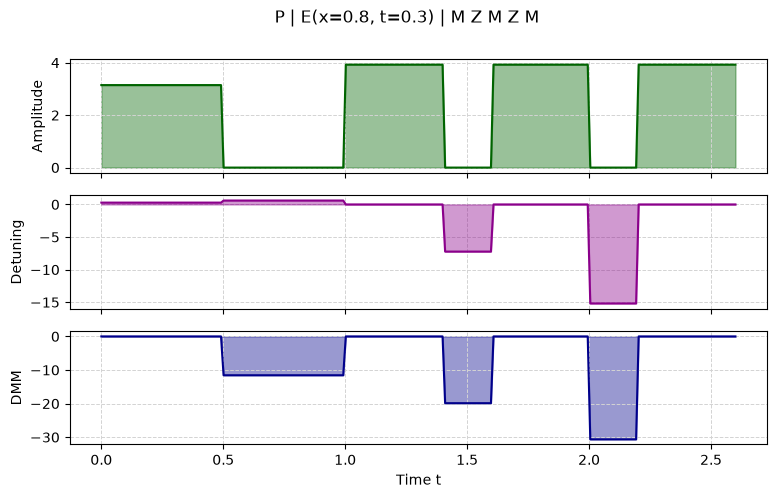

In [4]:
# Pulse schedule for one example point: Omega, global delta, DMM Delta (on atom 0).
# Horizontal axis = pulse time, not the PDE variable t.
theta_ex = np.random.default_rng(0).uniform(-np.pi, np.pi, 2 * K)
plt.figure(figsize=(9, 5))
make_program(0.8, 0.3, theta_ex).drive.draw()
plt.suptitle("P | E(x=0.8, t=0.3) | M Z M Z M")
plt.show()

In [5]:
def value_and_grad(f, x, t, theta):
    # f and df/dtheta at one point, two-term parameter-shift rule for every parameter
    val = f(x, t, theta)
    g = np.empty(len(theta))
    for k in range(len(theta)):
        e = np.zeros(len(theta))
        e[k] = SHIFT
        g[k] = (f(x, t, theta + e) - f(x, t, theta - e)) / 2
    return val, g


# Check the shift rules against central finite differences at one point (invariant model).
# h is not tiny on purpose: the QoolQit emulator has numerical noise of ~1e-5 to 1e-4 per run.
x0, t0, h = 0.7, 0.4, 0.05
e0 = np.eye(2 * K)[0]
checks = {
    "df/dx      ": ((f_inv(x0 + SHIFT, t0, theta_ex) - f_inv(x0 - SHIFT, t0, theta_ex)) / 2,
                    (f_inv(x0 + h, t0, theta_ex) - f_inv(x0 - h, t0, theta_ex)) / (2 * h)),
    "df/dt      ": ((f_inv(x0, t0 + SHIFT, theta_ex) - f_inv(x0, t0 - SHIFT, theta_ex)) / 2,
                    (f_inv(x0, t0 + h, theta_ex) - f_inv(x0, t0 - h, theta_ex)) / (2 * h)),
    "df/dtheta_0": ((f_inv(x0, t0, theta_ex + SHIFT * e0) - f_inv(x0, t0, theta_ex - SHIFT * e0)) / 2,
                    (f_inv(x0, t0, theta_ex + h * e0) - f_inv(x0, t0, theta_ex - h * e0)) / (2 * h)),
}
for name, (psr, fd) in checks.items():
    print(f"{name}  PSR {psr:+.5f}   finite diff {fd:+.5f}")

df/dx        PSR +0.60948   finite diff +0.60908
df/dt        PSR +0.12242   finite diff +0.12231
df/dtheta_0  PSR +0.08492   finite diff +0.08499


In [6]:
A = 0.5


def u0(x):
    return A * np.cos(x)


def du0(x):
    return -A * np.sin(x)


def source(x, t):
    return -A * np.sin(x + t)


def u_exact(x, t):
    return A * np.cos(x) * np.cos(t)


def m(t):                       # hard-constraint factor: m(0) = 0, even in t
    return 1.0 - np.cos(t)


def dm(t):
    return np.sin(t)


def u_model(f, x, t, theta):
    return u0(x) + m(t) * f(x, t, theta)


x_col = np.linspace(-np.pi, np.pi, 4, endpoint=False)          # spacing pi/2 = SHIFT
t_col = np.array([0.25, 0.5, 0.75, 1.0])
colloc = [(x, t) for t in t_col for x in x_col]                 # 16 collocation points


def cached(fun, theta):
    # fun(x, t, theta) evaluated once per distinct point. x is 2pi-periodic, so x-shifts by pi/2
    # land on grid points and are not run twice.
    cache = {}

    def g(x, t):
        key = (round((x + np.pi) % TWO_PI - np.pi, 9), round(t, 9))
        if key not in cache:
            cache[key] = fun(*key, theta)
        return cache[key]
    return g


def residuals(theta, f, history):
    # R = PDE residuals / sqrt(|C|),  loss = R @ R.   r = sin t f + (1 - cos t)(f_t + f_x) + u0' - s
    F = cached(f, theta)
    r = [dm(t) * F(x, t)
         + m(t) * ((F(x, t + SHIFT) - F(x, t - SHIFT)) / 2 + (F(x + SHIFT, t) - F(x - SHIFT, t)) / 2)
         + du0(x) - source(x, t) for x, t in colloc]
    return np.array(r) / np.sqrt(len(colloc))


def jacobian(theta, f, history):
    # dR/dtheta: shift rule in theta on top of the shift rule in x and t.
    # The same runs also give R, so the loss of every LM iterate is stored in `history` at no extra cost.
    G = cached(lambda x, t, th: value_and_grad(f, x, t, th), theta)
    r, rows = [], []
    for x, t in colloc:
        (v, g), (vtp, gtp), (vtm, gtm) = G(x, t), G(x, t + SHIFT), G(x, t - SHIFT)
        (vxp, gxp), (vxm, gxm) = G(x + SHIFT, t), G(x - SHIFT, t)
        r.append(dm(t) * v + m(t) * ((vtp - vtm) / 2 + (vxp - vxm) / 2) + du0(x) - source(x, t))
        rows.append(dm(t) * g + m(t) * ((gtp - gtm) / 2 + (gxp - gxm) / 2))
    r = np.array(r) / np.sqrt(len(colloc))
    history.append(float(r @ r))
    return np.array(rows) / np.sqrt(len(colloc))

## 5. Training

Both models are trained with `least_squares(method="lm")`.

**Settings.**

- Same starting points for both models: seeds 0, 1, 2.
- `xtol=1e-6`.
- `max_nfev=20`, which caps every run at fewer than 20 LM iterations.

**Recording.** `history` stores the loss at every LM iterate, i.e. at every Jacobian evaluation.

In [7]:
MODELS = {"plain QPINN": f_plain, "invariant QPINN": f_inv}
SEEDS = [0, 1, 2]
runs = []

for name, f in MODELS.items():
    for seed in SEEDS:
        theta0 = np.random.default_rng(seed).uniform(-np.pi, np.pi, 2 * K)
        history = []
        N_RUNS = 0
        tic = time.time()
        result = least_squares(residuals, theta0, jac=jacobian, method="lm", xtol=1e-6, max_nfev=20,
                               args=(f, history))
        if not np.isclose(history[-1], 2 * result.cost):
            history.append(2 * result.cost)           # final iterate, if LM stopped before evaluating its Jacobian
        runs.append(dict(model=name, seed=seed, theta=result.x.tolist(), loss=history,
                         circuit_runs=N_RUNS, seconds=time.time() - tic))
        print(f"{name:16s} seed {seed}: final loss {history[-1]:.2e}, {len(history) - 1} LM iterations, "
              f"{N_RUNS} circuit runs, {time.time() - tic:.0f}s")

plain QPINN      seed 0: final loss 9.96e-03, 11 LM iterations, 6144 circuit runs, 662s


plain QPINN      seed 1: final loss 6.73e-04, 12 LM iterations, 6576 circuit runs, 673s


plain QPINN      seed 2: final loss 3.08e-04, 10 LM iterations, 5616 circuit runs, 570s


invariant QPINN  seed 0: final loss 9.20e-05, 13 LM iterations, 14016 circuit runs, 1506s


invariant QPINN  seed 1: final loss 6.19e-06, 6 LM iterations, 7488 circuit runs, 776s


invariant QPINN  seed 2: final loss 3.80e-05, 12 LM iterations, 13056 circuit runs, 1341s


In [8]:
# Error against the exact solution on a grid (25 x 6 points per run)
xs = np.linspace(-np.pi, np.pi, 25)
ts = np.linspace(0.0, 1.0, 6)
for rec in runs:
    f, theta = MODELS[rec["model"]], np.array(rec["theta"])
    U = np.array([[u_model(f, x, t, theta) for x in xs] for t in ts])
    rec["max_error"] = float(np.abs(U - u_exact(xs[None, :], ts[:, None])).max())
    rec["U"] = U.tolist()

print(f"{'model':16s} {'seed':>4s} {'final loss':>11s} {'max |u - u*|':>13s} {'iterations':>10s} {'circuit runs':>12s}")
for rec in runs:
    print(f"{rec['model']:16s} {rec['seed']:4d} {rec['loss'][-1]:11.2e} {rec['max_error']:13.2e} "
          f"{len(rec['loss']) - 1:10d} {rec['circuit_runs']:12d}")

with open(os.path.join(RESULTS_DIR, f"results_{BACKEND}.json"), "w") as fh:
    json.dump(dict(backend=BACKEND, seeds=SEEDS, runs=runs, xs=xs.tolist(), ts=ts.tolist()), fh, indent=1)

model            seed  final loss  max |u - u*| iterations circuit runs
plain QPINN         0    9.96e-03      1.13e-01         11         6144
plain QPINN         1    6.73e-04      2.68e-02         12         6576
plain QPINN         2    3.08e-04      1.65e-02         10         5616
invariant QPINN     0    9.20e-05      9.57e-03         13        14016
invariant QPINN     1    6.19e-06      2.47e-03          6         7488
invariant QPINN     2    3.80e-05      6.25e-03         12        13056


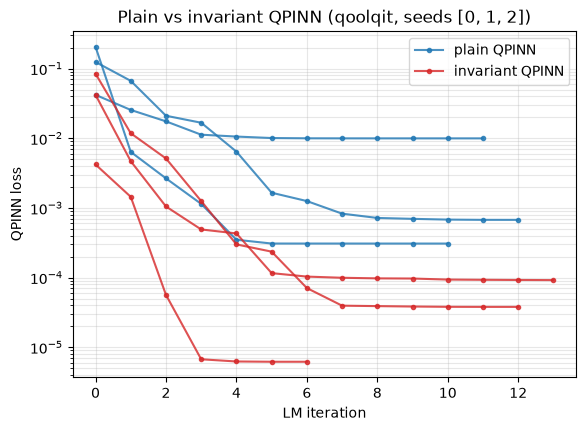

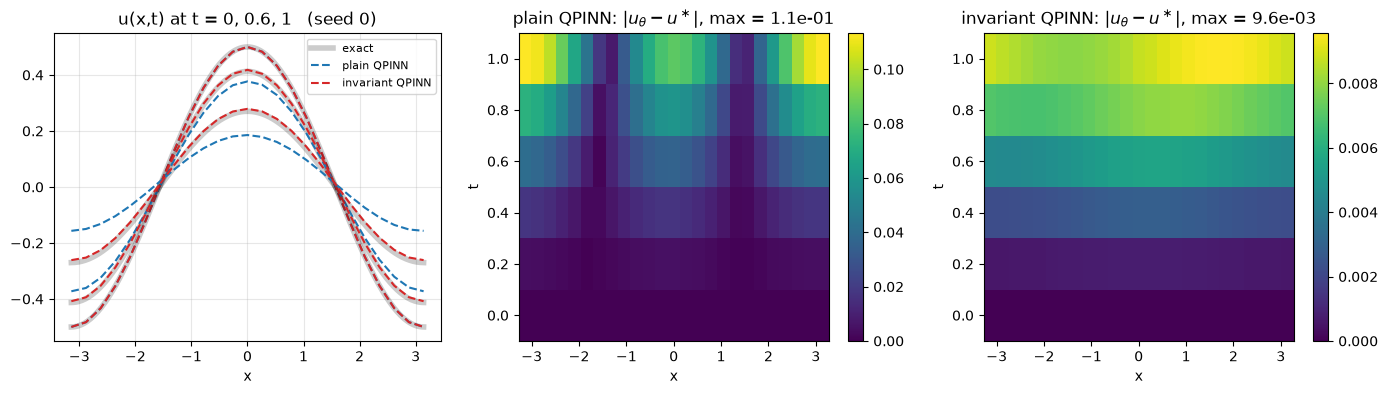

In [9]:
colors = {"plain QPINN": "C0", "invariant QPINN": "C3"}

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name in MODELS:
    for i, rec in enumerate(r for r in runs if r["model"] == name):
        ax.semilogy(rec["loss"], "o-", ms=3, color=colors[name], alpha=0.8,
                    label=name if i == 0 else None)
ax.set_xlabel("LM iteration")
ax.set_ylabel("QPINN loss")
ax.set_title(f"Plain vs invariant QPINN ({BACKEND}, seeds {SEEDS})")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.savefig(os.path.join(RESULTS_DIR, f"loss_{BACKEND}.png"), dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
xf = np.linspace(-np.pi, np.pi, 200)
for k, j in enumerate([0, 3, 5]):                                # t = 0, 0.6, 1
    ax[0].plot(xf, u_exact(xf, ts[j]), color="k", lw=4, alpha=0.2, label="exact" if k == 0 else None)
    for name in MODELS:
        rec = next(r for r in runs if r["model"] == name and r["seed"] == SEEDS[0])
        ax[0].plot(xs, np.array(rec["U"])[j], "--", color=colors[name], label=name if k == 0 else None)
ax[0].set_xlabel("x")
ax[0].set_title(f"u(x,t) at t = 0, 0.6, 1   (seed {SEEDS[0]})")
ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.3)
for a, name in zip(ax[1:], MODELS):
    rec = next(r for r in runs if r["model"] == name and r["seed"] == SEEDS[0])
    err = np.abs(np.array(rec["U"]) - u_exact(xs[None, :], ts[:, None]))
    im = a.pcolormesh(xs, ts, err, shading="auto")
    fig.colorbar(im, ax=a)
    a.set_xlabel("x")
    a.set_ylabel("t")
    a.set_title(rf"{name}: $|u_\theta-u^\ast|$, max = {err.max():.1e}")
fig.savefig(os.path.join(RESULTS_DIR, f"solution_{BACKEND}.png"), dpi=150, bbox_inches="tight")
plt.show()